In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data_banknote_authentication.txt to data_banknote_authentication.txt


In [ ]:
import pandas as pd

columns = ["variance", "skewness", "curtosis", "entropy", "class"]

df = pd.read_csv("data_banknote_authentication.txt",
                 header=None,
                 names=columns)

df.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0




*   Variance measures how spread out the wavelet coefficients are around the mean.

*  Kurtosis measures how heavy the tails of the distribution are (how many extreme values exist).

*   Entropy measures the amount of information or randomness in the image
*   Skewness measures the asymmetry of the distribution of wavelet coefficients.




In [ ]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

Shape of dataset: (1372, 5)

Column names:
Index(['variance', 'skewness', 'curtosis', 'entropy', 'class'], dtype='object')

Data types:
variance    float64
skewness    float64
curtosis    float64
entropy     float64
class         int64
dtype: object


In [ ]:
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64


In [ ]:
print("\nSummary statistics:")
print(df.describe())


Summary statistics:
          variance     skewness     curtosis      entropy        class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625     3.179250     0.394810     1.000000
max       6.824800    12.951600    17.927400     2.449500     1.000000


Roughly 44.5% of my data belongs to class 1, and the remaining 55.5% belongs to class 0.


*   skewness spans from roughly -13.7 to +12.9 with a high standard deviation (5.87).
*   variance has a range (-7.0 to +6.8) and standard deviation (2.84).




Thus, the features are on different scales.


*   Curtosis is Right-Skewed: The mean (1.39) is significantly higher than the median (0.61). Furthermore, the 75th percentile is 3.17, but the maximum value jumps all the way to 17.92. This indicates a long "right tail" with potentially some extreme high-value outliers.
*   Entropy is Left-Skewed: The mean (-1.19) is lower than the median (-0.58), and the vast majority of the data points are negative.
*  Variance is relatively symmetric: The mean (0.43) and median (0.49) are quite close to one another, suggesting a somewhat normal (bell-shaped) distribution without extreme outliers

In [ ]:
print("\nClass distribution:")
print(df["class"].value_counts())


Class distribution:
class
0    762
1    610
Name: count, dtype: int64


In [ ]:
print("\nCorrelation matrix:")
print(df.corr())


Correlation matrix:
          variance  skewness  curtosis   entropy     class
variance  1.000000  0.264026 -0.380850  0.276817 -0.724843
skewness  0.264026  1.000000 -0.786895 -0.526321 -0.444688
curtosis -0.380850 -0.786895  1.000000  0.318841  0.155883
entropy   0.276817 -0.526321  0.318841  1.000000 -0.023424
class    -0.724843 -0.444688  0.155883 -0.023424  1.000000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

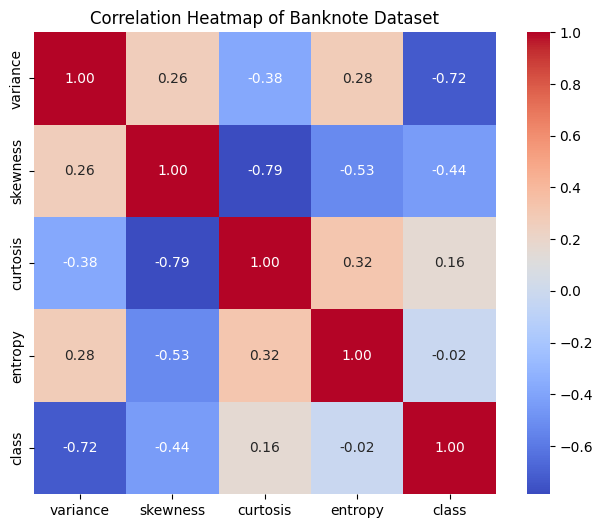

In [ ]:
corr_matrix = df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            square=True)

plt.title("Correlation Heatmap of Banknote Dataset")
plt.show()

Observation 1: the correlation between entropy and class is -0.02. This is incredibly close to 0, meaning entropy has almost no linear relationship with whether a banknote is fake or real.

Observation 2: multicollinearity between skewness and curtosis. They have a strong negative correlation of -0.79.

Observation 3: variance has a strong negative correlation with class (-0.72)

Multicollinearity and low correlated parameter were identified. However, since SVM models can capture nonlinear relationships, no features were removed at this stage. Feature elimination may be considered later if it negatively affects model performance or computational efficiency, and decisions will be based on empirical evaluation.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(["class"], axis=1)
y = df["class"]

# Split into train (70%) and temporary set (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Split temporary set into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train set size:", X_train.shape)
print("Validation set size:", X_val.shape)
print("Test set size:", X_test.shape)

Train set size: (960, 4)
Validation set size: (206, 4)
Test set size: (206, 4)


The 50:25:25 rule is a classic standard (the recommended split in lectures), but it assumes you have so much data that 50% is plenty for the model to reach its maximum potential. If I used the 50:25:25 split, my SVM would only be trained on 686 examples. By shifting to a 70:15:15 split, I feed the model 960 examples for training. The remaining 30% is split equally into validation (15%, 206 samples) and test (15%, 206 samples) sets. My dataset is well-balanced, 206 samples are more than enough to evaluate hyperparameter $C$ and calculate  $F_2$-score.

In [ ]:
#Verifying class balance in each split
print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation class distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))


Train class distribution:
class
0    0.555208
1    0.444792
Name: proportion, dtype: float64

Validation class distribution:
class
0    0.553398
1    0.446602
Name: proportion, dtype: float64

Test class distribution:
class
0    0.558252
1    0.441748
Name: proportion, dtype: float64


In [ ]:
import numpy as np

# Compute statistics on TRAINING data
mean_X = X_train.mean()
mean_X2 = (X_train**2).mean()

# Compute denominator sqrt(E[X^2] - (E[X])^2)
std_X = np.sqrt(mean_X2 - mean_X**2)

# Standardize datasets
X_train_std = (X_train - mean_X) / std_X
X_val_std   = (X_val - mean_X) / std_X
X_test_std  = (X_test - mean_X) / std_X

# check result
X_train_std.head()

,variance,skewness,curtosis,entropy
1203,-2.546572,0.871097,-0.157933,-3.048572
1205,-0.762762,-0.555813,0.144170,0.822437
606,-0.679593,1.706474,-0.218003,-2.766581
116,1.192026,0.944256,-0.731325,0.639775
694,0.082511,-0.259688,0.190494,0.803921


In [ ]:
# Verifying standadization
print("Means after standardization:")
print(X_train_std.mean())

print("\nVariances after standardization:")
print(X_train_std.var())

Means after standardization:
variance    8.326673e-18
skewness   -3.330669e-17
curtosis    0.000000e+00
entropy    -5.551115e-18
dtype: float64

Variances after standardization:
variance    1.001043
skewness    1.001043
curtosis    1.001043
entropy     1.001043
dtype: float64


In [ ]:
# Import necessary metrics and SVM classifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, fbeta_score
import pandas as pd
from IPython.display import display

In [ ]:
# Function to calculate all required metrics
def evaluate_model(model, X, y, beta=2):
    y_pred = model.predict(X)
    error_rate = 1 - accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred, zero_division=0)
    recall = recall_score(y, y_pred, zero_division=0)
    f_beta = fbeta_score(y, y_pred, beta=beta, zero_division=0)
    return error_rate, precision, recall, f_beta

In [ ]:
# Define candidate C values
C_candidates_I = [0.01, 0.1, 1, 10, 100]

results_train = []
results_val = []

In [ ]:
# ==========================================
# Tasks 7, 8, 9: Model I (Linear SVM)
# ==========================================
print("Evaluating Model I (Linear Kernel)...")
best_C_I = None
best_fbeta_I = -1

for C in C_candidates_I:
    # Train Model I
    clf_I = SVC(C=C, kernel='linear', random_state=42)
    clf_I.fit(X_train_std, y_train)

    # Training metrics
    err_train, prec_train, rec_train, _ = evaluate_model(clf_I, X_train_std, y_train)
    n_support = sum(clf_I.n_support_) # Total number of support vectors

    # Validation metrics
    err_val, prec_val, rec_val, fbeta_val = evaluate_model(clf_I, X_val_std, y_val, beta=2)

    # Store results
    results_train.append({'Model': 'I (Linear)', 'C': C, 'Error Rate': err_train,
                          'Precision': prec_train, 'Recall': rec_train, 'Support Vectors': n_support})

    results_val.append({'Model': 'I (Linear)', 'C': C, 'Error Rate': err_val,
                        'Precision': prec_val, 'Recall': rec_val, 'F2-Score': fbeta_val})

    # Select best C based on F2-score on the validation set
    if fbeta_val > best_fbeta_I:
        best_fbeta_I = fbeta_val
        best_C_I = C

print(f"Best C for Model I: {best_C_I}\n")

Evaluating Model I (Linear Kernel)...
Best C for Model I: 10



In [ ]:
# ==========================================
# Tasks 10, 11: Models II, III, IV
# ==========================================

C_candidates_kernels = [0.1, 1, 10, 100, 1000]

# Models II, III, IV
models_config = {
    'II (Poly)': {'kernel': 'poly', 'degree': 3, 'coef0': 1},
    'III (RBF)': {'kernel': 'rbf', 'gamma': 'scale'},
    'IV (Sigmoid)': {'kernel': 'sigmoid', 'coef0': 0, 'gamma': 'scale'}
}

best_C = {'I (Linear)': best_C_I}
best_models = {}

In [ ]:
# Retrain and save the best Model I
best_models['I (Linear)'] = SVC(C=best_C_I, kernel='linear', random_state=42).fit(X_train_std, y_train)

for model_name, config in models_config.items():
    print(f"Evaluating Model {model_name}...")
    best_C_current = None
    best_fbeta_current = -1
    best_clf_current = None

    for C in C_candidates_kernels:
        clf = SVC(C=C, random_state=42, **config)
        clf.fit(X_train_std, y_train)

        # Training metrics
        err_train, prec_train, rec_train, _ = evaluate_model(clf, X_train_std, y_train)
        n_support = sum(clf.n_support_)

        # Validation metrics
        err_val, prec_val, rec_val, fbeta_val = evaluate_model(clf, X_val_std, y_val, beta=2)

        results_train.append({'Model': model_name, 'C': C, 'Error Rate': err_train,
                              'Precision': prec_train, 'Recall': rec_train, 'Support Vectors': n_support})

        results_val.append({'Model': model_name, 'C': C, 'Error Rate': err_val,
                            'Precision': prec_val, 'Recall': rec_val, 'F2-Score': fbeta_val})

        # Choose best C for current model
        if fbeta_val > best_fbeta_current:
            best_fbeta_current = fbeta_val
            best_C_current = C
            best_clf_current = clf

    best_C[model_name] = best_C_current
    best_models[model_name] = best_clf_current
    print(f"Best C for Model {model_name}: {best_C_current}\n")

Evaluating Model II (Poly)...
Best C for Model II (Poly): 1

Evaluating Model III (RBF)...
Best C for Model III (RBF): 1

Evaluating Model IV (Sigmoid)...
Best C for Model IV (Sigmoid): 0.1



In [ ]:
# Displaying the tables for Training and Validation
df_train = pd.DataFrame(results_train)
df_val = pd.DataFrame(results_val)

print("\n" + "="*40)
print(" TRAINING SET ESTIMATIONS ")
print("="*40)
display(df_train)

print("\n" + "="*40)
print(" VALIDATION SET ESTIMATIONS ")
print("="*40)
display(df_val)


 TRAINING SET ESTIMATIONS 


,Model,C,Error Rate,Precision,Recall,Support Vectors
0,I (Linear),0.01,0.021875,0.959276,0.992974,407
1,I (Linear),0.10,0.014583,0.968254,1.000000,140
2,I (Linear),1.00,0.013542,0.972603,0.997658,59
3,I (Linear),10.00,0.007292,0.986111,0.997658,34
4,I (Linear),100.00,0.011458,0.985981,0.988290,24
5,II (Poly),0.10,0.006250,0.986143,1.000000,121
6,II (Poly),1.00,0.000000,1.000000,1.000000,38
7,II (Poly),10.00,0.000000,1.000000,1.000000,17
8,II (Poly),100.00,0.000000,1.000000,1.000000,12
9,II (Poly),1000.00,0.000000,1.000000,1.000000,12



 VALIDATION SET ESTIMATIONS 


,Model,C,Error Rate,Precision,Recall,F2-Score
0,I (Linear),0.01,0.024272,0.948454,1.000000,0.989247
1,I (Linear),0.10,0.019417,0.958333,1.000000,0.991379
2,I (Linear),1.00,0.019417,0.958333,1.000000,0.991379
3,I (Linear),10.00,0.009709,0.978723,1.000000,0.995671
4,I (Linear),100.00,0.014563,0.978495,0.989130,0.986985
5,II (Poly),0.10,0.009709,0.978723,1.000000,0.995671
6,II (Poly),1.00,0.000000,1.000000,1.000000,1.000000
7,II (Poly),10.00,0.000000,1.000000,1.000000,1.000000
8,II (Poly),100.00,0.000000,1.000000,1.000000,1.000000
9,II (Poly),1000.00,0.000000,1.000000,1.000000,1.000000


In [ ]:
# ==========================================
# Task 12: Final Evaluation on Test Set
# ==========================================
results_test = []

for model_name, clf in best_models.items():
    # Evaluate best model variant on the completely unseen TEST set
    err_test, prec_test, rec_test, fbeta_test = evaluate_model(clf, X_test_std, y_test, beta=2)

    results_test.append({
        'Model': model_name,
        'Best C': best_C[model_name],
        'Test Error Rate': err_test,
        'Test Precision': prec_test,
        'Test Recall': rec_test,
        'Test F2-Score': fbeta_test
    })

df_test = pd.DataFrame(results_test)

print("\n" + "="*40)
print(" Final estimation on the test set ")
print("="*40)
display(df_test)


 Final estimation on the test set 


,Model,Best C,Test Error Rate,Test Precision,Test Recall,Test F2-Score
0,I (Linear),10.0,0.009709,0.978495,1.000000,0.995624
1,II (Poly),1.0,0.000000,1.000000,1.000000,1.000000
2,III (RBF),1.0,0.000000,1.000000,1.000000,1.000000
3,IV (Sigmoid),0.1,0.145631,0.842697,0.824176,0.827815
